In [2]:
!ls

sample_data


In [3]:
!ls

 sample_data  'statlog+german+credit+data (1).zip'


In [4]:
!unzip "statlog+german+credit+data (1).zip"

Archive:  statlog+german+credit+data (1).zip
  inflating: german.data             
  inflating: german.data-numeric     
  inflating: german.doc              
  inflating: Index                   


In [5]:
import pandas as pd

df = pd.read_csv('/content/german.data-numeric', sep='\s+', header=None)

print(df.shape)
df.head()

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_584/2104008288.py:3: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv('/content/german.data-numeric', sep='\s+', header=None)


(1000, 25)


,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,1,6,4,12,5,5,3,4,1,67,...,0,0,1,0,0,1,0,0,1,1
1,2,48,2,60,1,3,2,2,1,22,...,0,0,1,0,0,1,0,0,1,2
2,4,12,4,21,1,4,3,3,1,49,...,0,0,1,0,0,1,0,1,0,1
3,1,42,2,79,1,4,3,4,2,45,...,0,0,0,0,0,0,0,0,1,1
4,1,24,3,49,1,3,3,4,4,53,...,1,0,1,0,0,0,0,0,1,2


In [6]:
df.columns = [f'Feature_{i}' for i in range(1,25)] + ['Target']

df.head()

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,...,Feature_16,Feature_17,Feature_18,Feature_19,Feature_20,Feature_21,Feature_22,Feature_23,Feature_24,Target
0,1,6,4,12,5,5,3,4,1,67,...,0,0,1,0,0,1,0,0,1,1
1,2,48,2,60,1,3,2,2,1,22,...,0,0,1,0,0,1,0,0,1,2
2,4,12,4,21,1,4,3,3,1,49,...,0,0,1,0,0,1,0,1,0,1
3,1,42,2,79,1,4,3,4,2,45,...,0,0,0,0,0,0,0,0,1,1
4,1,24,3,49,1,3,3,4,4,53,...,1,0,1,0,0,0,0,0,1,2


In [7]:
print(df['Target'].value_counts())

Target
1    700
2    300
Name: count, dtype: int64


Accuracy : 0.795
Precision: 0.8012048192771084
Recall   : 0.9432624113475178
F1 Score : 0.8664495114006515


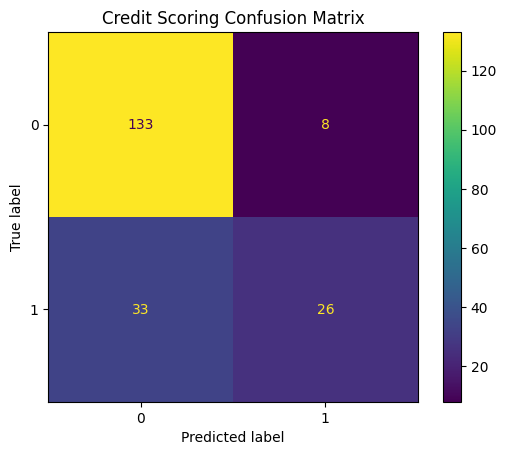

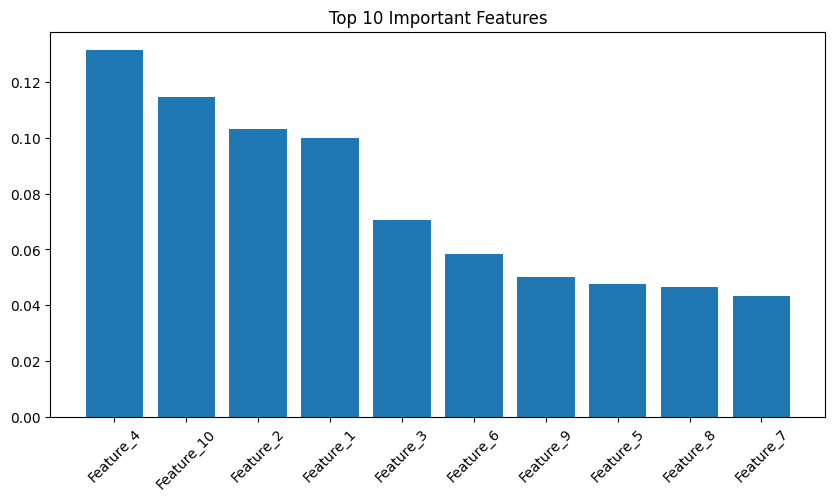

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

X = df.drop('Target', axis=1)
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, pos_label=1))
print("Recall   :", recall_score(y_test, y_pred, pos_label=1))
print("F1 Score :", f1_score(y_test, y_pred, pos_label=1))
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Credit Scoring Confusion Matrix")
plt.show()
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,5))
plt.bar(
    importance['Feature'][:10],
    importance['Importance'][:10]
)

plt.xticks(rotation=45)
plt.title("Top 10 Important Features")
plt.show()